In [1]:
#Environment Test
#%%
import torch
import pytorch3d
from pytorch3d.ops import knn_points


#%%
print(pytorch3d.__version__)
print(f"torch version: {torch.__version__}")
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
!python --version

#%%
p1 = torch.rand((1, 100, 3), device='cuda')
p2 = torch.rand((1, 200, 3), device='cuda')
knn = knn_points(p1, p2, K=1)
print("KNN distances shape:", knn.dists.shape)


#%%


0.7.8
torch version: 2.2.0+cu121
CUDA available: True
CUDA version: 12.1
Python 3.11.5
KNN distances shape: torch.Size([1, 100, 1])


In [2]:
# =====================================================
# Conditional AutoEncoder (cAE) for G-code Layers (5-Fold CV)
# Conditions: areas_norm (continuous) + label one-hot (categorical)
# =====================================================
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# === Imports ===
import random
from sklearn.model_selection import KFold
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from box import Box
from tqdm import tqdm
from pathlib import Path
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pytorch3d.loss import chamfer_distance
import torch.nn.functional as F

# === Config ===
with open("config.yaml", "r") as file:
    args = Box(yaml.safe_load(file))

args.data_dir = Path.home() / args.data_dir
args.model_dir = Path.home() / args.model_dir
args.output_folder = Path(args.output_folder)
args.output_folder.mkdir(parents=True, exist_ok=True)

# === Load Dataset (Dictionary) ===
data_file = args.data_dir / args.dataset
dataset_dict = np.load(data_file, allow_pickle=True).item()

raw_pc_array   = dataset_dict["data"]            # (num_files, max_layers, max_points, 2)
layer_indices  = dataset_dict["layer_indices"]   # (num_files, max_layers)
labels    = dataset_dict["labels"]          # (num_files,) int label per file
label_map      = dataset_dict["label_map"]       # dict name->int
areas_norm = dataset_dict["areas_norm"]      # (num_files, max_layers) in [0,1]

num_classes = len(label_map)

print("✅ Loaded dataset")
print(f"Data shape: {raw_pc_array.shape}")
print(f"Label map: {label_map} (num_classes={num_classes})")
print(f"Layer indices shape: {layer_indices.shape}")
print(f"areas_norm shape: {areas_norm.shape}")
# === Flatten valid layers across files (keep area + label) ===
flat = []  # list of (points, area, label)

for f in range(len(raw_pc_array)):           # loop files
    layers = raw_pc_array[f]  # list of accepted layers (variable length)
    areas  = areas_norm[f]
    label  = labels[f]

    for l in range(len(layers)):              # loop accepted layers
        pc = layers[l]                        # (P,2)

        # remove zero rows if any
        pc = pc[~np.all(pc == 0, axis=1)]

        if pc.shape[0] < 10:
            continue

        flat.append((pc, areas[l], label))

print(f"✅ Flattened total valid layers: {len(flat)}")

# === Compute max number of points among valid layers ===
max_points = max(pts.shape[0] for (pts, _, _) in flat)
print(f"✅ Max points in any layer: {max_points}")

pts_list, area_list, label_list = [], [], []

for (pts, area_norm_scalar, label_f) in flat:
    # pts already normalized & resampled in dataset
    if pts.shape[0] != max_points:
        continue
    pts_list.append(pts)
    area_list.append(area_norm_scalar)
    label_list.append(label_f)

pc_array   = np.array(pts_list, dtype=np.float32)                   # (N,P,2)
area_array = np.array(area_list, dtype=np.float32).reshape(-1, 1)   # (N,1)
label_int  = np.array(label_list, dtype=np.int64)                   # (N,)

print("✅ Data after normalization:")
print(f"points: {pc_array.shape}, areas_norm: {area_array.shape}, labels: {label_int.shape}")

# === Dataset Class (returns points, area_norm, label_onehot) ===
class PointDataset(Dataset):
    def __init__(self, points_np, areas_np, label_int_np, num_classes):
        self.points = torch.tensor(points_np, dtype=torch.float32)              # (N,P,2)
        self.areas  = torch.tensor(areas_np, dtype=torch.float32)               # (N,1)
        self.labels = torch.tensor(label_int_np, dtype=torch.long)              # (N,)
        self.num_classes = num_classes

    def __len__(self):
        return self.points.shape[0]

    def __getitem__(self, idx):
        x   = self.points[idx]                         # (P,2)
        a   = self.areas[idx]                          # (1,)
        y   = self.labels[idx]                         # ()
        y1h = F.one_hot(y, num_classes=self.num_classes).float()  # (C,)
        return x, a, y1h

dataset = PointDataset(pc_array, area_array, label_int, num_classes)

# === Model: cAE (decoder conditioned on area + label) ===
class PointCloudCAE(torch.nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        """
        point_size: P (number of points)
        latent_size: dim of latent z
        cond_dim: 1 (area) + num_classes (label one-hot)
        """
        super().__init__()
        self.P = point_size
        self.enc = torch.nn.Sequential(
            torch.nn.Linear(point_size * 2, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, latent_size),
        )
        self.dec = torch.nn.Sequential(
            torch.nn.Linear(latent_size + cond_dim, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, point_size * 2),
        )

    def forward(self, x, cond):
        """
        x: (B,P,2)
        cond: (B, cond_dim)  = [area_norm (B,1) || label_onehot (B,C)]
        """
        B = x.shape[0]
        x_flat = x.view(B, -1)
        z = self.enc(x_flat)              # (B, latent)
        zc = torch.cat([z, cond], dim=1)  # (B, latent + cond)
        out_flat = self.dec(zc)           # (B, P*2)
        out = out_flat.view(B, self.P, 2)
        return out

# === Setup ===
device = 'cuda'  # if torch.cuda.is_available() else 'cpu'
point_size = pc_array.shape[1]
cond_dim = 1 + num_classes

# === Train/Test ===
def train_epoch(train_loader, cae, optimizer):
    cae.train()
    total = 0.0
    for i, batch in enumerate(train_loader):
        x, a, y1h = batch
        x = x.to(device)
        a = a.to(device)          # (B,1)
        y1h = y1h.to(device)      # (B,C)
        cond = torch.cat([a, y1h], dim=1)  # (B, 1+C)

        optimizer.zero_grad()
        x_hat = cae(x, cond)
        loss, _ = chamfer_distance(x, x_hat)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / (i + 1)

def test_epoch(test_loader, cae):
    cae.eval()
    total = 0.0
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            x, a, y1h = batch
            x = x.to(device)
            a = a.to(device)
            y1h = y1h.to(device)
            cond = torch.cat([a, y1h], dim=1)
            x_hat = cae(x, cond)
            loss, _ = chamfer_distance(x, x_hat)
            total += loss.item()
    return total / (i + 1)

# === Plotting reconstructions ===
def plotPCbatch_2d(batch_input, batch_output, labels, areas, show=True, save=False, name="plot"):
    batch_input = batch_input.cpu().numpy()
    batch_output = batch_output.cpu().numpy()
    cols = min(5, batch_input.shape[0])
    fig, axs = plt.subplots(2, cols, figsize=(3.0*cols, 5))
    if cols == 1:
        axs = np.array([[axs[0]], [axs[1]]])
    for i in range(cols):
        axs[0, i].scatter(batch_input[i, :, 0], batch_input[i, :, 1], c='b', s=2)
        axs[1, i].scatter(batch_output[i, :, 0], batch_output[i, :, 1], c='r', s=2)
        axs[0, i].axis('equal'); axs[1, i].axis('equal')
        axs[0, i].grid(True); axs[1, i].grid(True)
        axs[0, i].set_title(f"Input\nLabel={labels[i]}, Area={areas[i]:.3f}")
        axs[1, i].set_title("Recon")
    plt.tight_layout()
    if save:
        plt.savefig(f"{name}.png")
        plt.close()
    elif show:
        plt.show()

# === 5-Fold Cross Validation ===
kf = KFold(n_splits=3, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(range(len(dataset))), 1):
    print(f"\n==== Fold {fold} ====")

    # Subsets & loaders
    train_ds = torch.utils.data.Subset(dataset, train_idx)
    test_ds  = torch.utils.data.Subset(dataset, test_idx)

    train_loader = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=args.batch_size, shuffle=False, num_workers=0)

    # Model + optimizer
    cae = PointCloudCAE(point_size, args.latent_size, cond_dim).to(device)
    optimizer = optim.AdamW(cae.parameters(), lr=1e-3, weight_decay=1e-5)

    train_losses, test_losses = [], []

    for epoch in range(args.ae_epoch):
        train_loss = train_epoch(train_loader, cae, optimizer)
        test_loss  = test_epoch(test_loader, cae)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        print(f"Fold {fold} | Epoch {epoch}: Train={train_loss:.4f}, Test={test_loss:.4f}")

        # Save loss curve every epoch (overwrites, so always up-to-date)
        plt.figure(figsize=(8,5))
        plt.plot(train_losses, label="Train Loss")
        plt.plot(test_losses, label="Test Loss")
        plt.xlabel("Epoch"); plt.ylabel("Chamfer Loss")
        plt.title(f"Fold {fold} Loss Curve (up to epoch {epoch})")
        plt.legend(); plt.grid(True)
        plt.savefig(args.output_folder / f"fold{fold}_loss.png")
        plt.close()

        # Save reconstructions + model every 50 epochs
        if epoch % 50 == 0:
            n_samples = min(5, len(test_ds))
            rand_indices = random.sample(range(len(test_ds)), n_samples)
            batch_in = []
            cond_in  = []
            for idx in rand_indices:
                x, a, y1h = test_ds[idx]
                batch_in.append(x)
                cond_in.append(torch.cat([a, y1h], dim=0))
            batch_in = torch.stack(batch_in).to(device)               # (B,P,2)
            cond_in  = torch.stack(cond_in).to(device)                # (B,1+C)
            with torch.no_grad():
                out = cae(batch_in, cond_in)
            plotPCbatch_2d(
                batch_in,
                out.cpu(),
                labels=[int(torch.argmax(y1h).item()) for (_, _, y1h) in [test_ds[i] for i in rand_indices]],
                areas=[float(test_ds[i][1].item()) for i in rand_indices],
                save=True,
                name=args.output_folder / f"fold{fold}_epoch{epoch}"
            )
            torch.save(cae.state_dict(), args.model_dir / f"cae_fold{fold}_epoch{epoch}.pt")

    # Save fold-specific model
    torch.save(cae.state_dict(), args.model_dir / f"cae_fold{fold}.pt")

print("✅ 5-Fold Conditional AE training complete. Models saved.")


✅ Loaded dataset
Data shape: (10, 590, 2900, 2)
Label map: {'cube': 0, 'cylinder': 1, 'flange': 2, 'gear_bevel': 3, 'gear_spur': 4, 'lead_screw': 5, 'nut': 6, 'propeller': 7, 'pyramid': 8, 'sphere': 9} (num_classes=10)
Layer indices shape: (10, 590)
areas_norm shape: (10, 590)
✅ Flattened total valid layers: 5900
✅ Max points in any layer: 2900
✅ Data after normalization:
points: (5900, 2900, 2), areas_norm: (5900, 1), labels: (5900,)

==== Fold 1 ====
Fold 1 | Epoch 0: Train=0.0276, Test=0.0056
Fold 1 | Epoch 1: Train=0.0044, Test=0.0037
Fold 1 | Epoch 2: Train=0.0033, Test=0.0031
Fold 1 | Epoch 3: Train=0.0027, Test=0.0027
Fold 1 | Epoch 4: Train=0.0023, Test=0.0024
Fold 1 | Epoch 5: Train=0.0021, Test=0.0023
Fold 1 | Epoch 6: Train=0.0020, Test=0.0022
Fold 1 | Epoch 7: Train=0.0019, Test=0.0023
Fold 1 | Epoch 8: Train=0.0018, Test=0.0023
Fold 1 | Epoch 9: Train=0.0018, Test=0.0021
Fold 1 | Epoch 10: Train=0.0017, Test=0.0022
Fold 1 | Epoch 11: Train=0.0016, Test=0.0019
Fold 1 | Epoc

✅ Dataset loaded
✅ Flattened data: (5900, 2900, 2)
✅ Model loaded


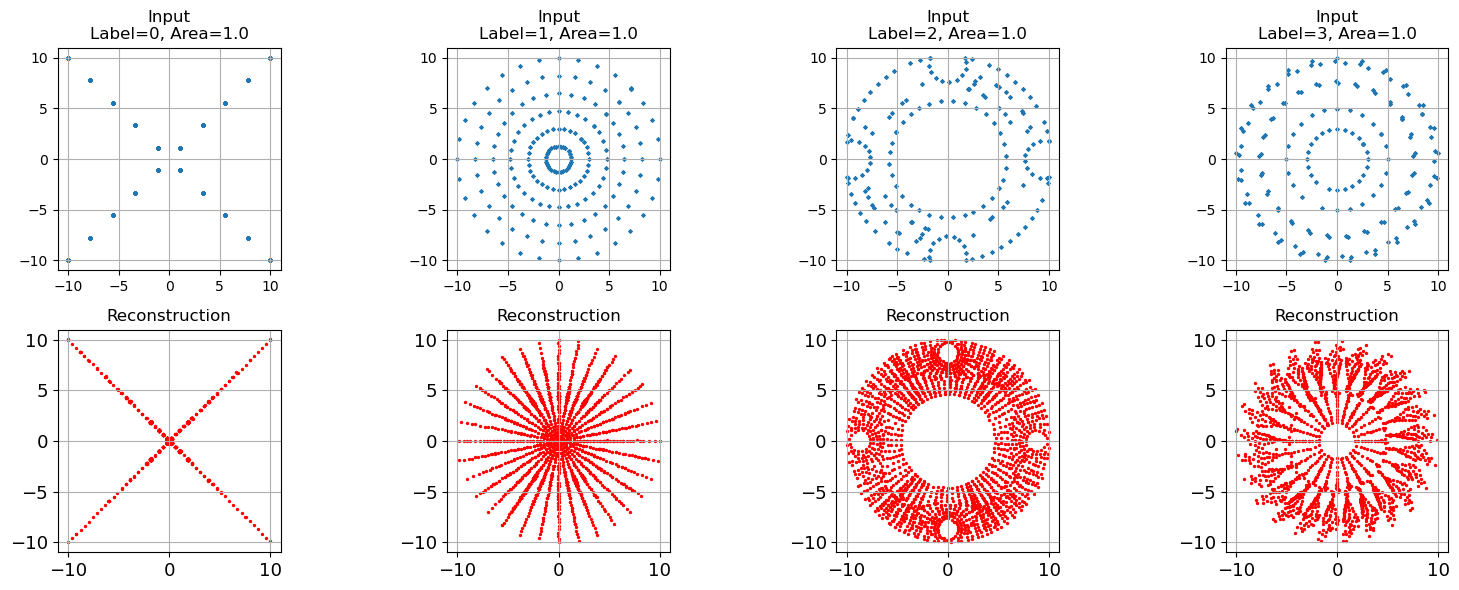

✅ Deterministic inference complete


In [13]:
# =====================================================
# FULL INFERENCE CODE
# Conditional AutoEncoder (cAE)
# Fixed labels [0,1,2,3], area = 1.0
# =====================================================

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch.nn.functional as F

# =====================================================
# USER PATHS (EDIT THESE)
# =====================================================
DATA_PATH  = Path.home() / "F:\JupyterWork\Testing GAN\CGAN V2 for AMF\DatasetRV1\gcode_layers_V1.npy"
MODEL_PATH = Path.home() / "F:\JupyterWork\Testing GAN\CGAN V2 for AMF\ModelAEV4\cae_fold3.pt"

# =====================================================
# DEVICE
# =====================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# LOAD DATASET
# =====================================================
dataset_dict = np.load(DATA_PATH, allow_pickle=True).item()

raw_pc_array  = dataset_dict["data"]
areas_norm    = dataset_dict["areas_norm"]
labels        = dataset_dict["labels"]
label_map     = dataset_dict["label_map"]

num_classes = len(label_map)

print("✅ Dataset loaded")

# =====================================================
# REBUILD FLAT DATA (EXACT TRAINING LOGIC)
# =====================================================
flat = []
for f in range(len(raw_pc_array)):
    for l in range(len(raw_pc_array[f])):
        pc = raw_pc_array[f][l]
        pc = pc[~np.all(pc == 0, axis=1)]
        if pc.shape[0] < 10:
            continue
        flat.append((pc, areas_norm[f][l], labels[f]))

max_points = max(p.shape[0] for (p, _, _) in flat)

pts, areas, lbls = [], [], []
for p, a, y in flat:
    if p.shape[0] == max_points:
        pts.append(p)
        areas.append(a)
        lbls.append(y)

pc_array   = np.array(pts, dtype=np.float32)               # (N,P,2)
area_array = np.array(areas, dtype=np.float32).reshape(-1,1)
label_int  = np.array(lbls, dtype=np.int64)

print("✅ Flattened data:", pc_array.shape)

# =====================================================
# MODEL DEFINITION (MUST MATCH TRAINING)
# =====================================================
class PointCloudCAE(torch.nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = torch.nn.Sequential(
            torch.nn.Linear(point_size * 2, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, latent_size),
        )
        self.dec = torch.nn.Sequential(
            torch.nn.Linear(latent_size + cond_dim, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, point_size * 2),
        )

    def forward(self, x, cond):
        B = x.shape[0]
        z = self.enc(x.view(B, -1))
        zc = torch.cat([z, cond], dim=1)
        out = self.dec(zc).view(B, self.P, 2)
        return out

# =====================================================
# LOAD MODEL
# =====================================================
point_size  = pc_array.shape[1]
latent_size = 512                  # MUST MATCH TRAINING
cond_dim    = 1 + num_classes

cae = PointCloudCAE(point_size, latent_size, cond_dim).to(device)
cae.load_state_dict(torch.load(MODEL_PATH, map_location=device))
cae.eval()

print("✅ Model loaded")

# =====================================================
# FIXED INFERENCE SETTINGS
# =====================================================
TARGET_LABELS = [0, 1, 2, 3]
AREA_COND = 1.0

inputs = []
conds  = []
labels_used = []

for lbl in TARGET_LABELS:
    idx = np.where(label_int == lbl)[0][0]

    x = torch.tensor(pc_array[idx], dtype=torch.float32)
    a = torch.tensor([[AREA_COND]], dtype=torch.float32)
    y = torch.tensor(lbl, dtype=torch.long)
    y1h = F.one_hot(y, num_classes=num_classes).float().unsqueeze(0)

    cond = torch.cat([a, y1h], dim=1)

    inputs.append(x)
    conds.append(cond)
    labels_used.append(lbl)

inputs = torch.stack(inputs).to(device)     # (4,P,2)
conds  = torch.cat(conds).to(device)        # (4,1+C)

# =====================================================
# INFERENCE
# =====================================================
with torch.no_grad():
    outputs = cae(inputs, conds)

inputs_np  = inputs.cpu().numpy()
outputs_np = outputs.cpu().numpy()

# =====================================================
# SCALE TO [-10, 10]
# =====================================================
SCALE = 10.0
inputs_np  = inputs_np  * SCALE
outputs_np = outputs_np * SCALE

# =====================================================
# PLOT (ONE ROW)
# =====================================================
cols = len(TARGET_LABELS)
fig, axs = plt.subplots(2, cols, figsize=(4*cols, 6))
AX_MIN = -11
AX_MAX = 11

for i in range(cols):
    # INPUT
    axs[0, i].scatter(inputs_np[i,:,0], inputs_np[i,:,1], s=2)
    axs[0, i].set_title(f"Input\nLabel={labels_used[i]}, Area=1.0")
    axs[0, i].set_xlim(AX_MIN, AX_MAX)
    axs[0, i].set_ylim(AX_MIN, AX_MAX)
    axs[0, i].set_aspect('equal', adjustable='box')
    axs[0, i].grid(True)

    # OUTPUT
    axs[1, i].scatter(outputs_np[i,:,0], outputs_np[i,:,1], s=2, c="r")
    axs[1, i].set_title("Reconstruction")
    axs[1, i].set_xlim(AX_MIN, AX_MAX)
    axs[1, i].set_ylim(AX_MIN, AX_MAX)
    axs[1, i].tick_params(axis='both', labelsize=13)
    axs[1, i].set_aspect('equal', adjustable='box')
    axs[1, i].grid(True)
plt.tight_layout()
plt.savefig("AE GENERATION.png", dpi=600, bbox_inches="tight")
plt.show()

print("✅ Deterministic inference complete")
